In [2]:
import pandas as pd
import numpy as np

np.random.seed(50)
total_clicks = 6000

devices = ['Mobile', 'Desktop', 'Tablet', 'BOT_UNKNOWN']
search_terms = [' leather shoes ', 'IPHONE 14', 'summer dress', '  shoes leather  ', 'N/A', None]

data = {
    'Session_ID': [f"SESS-{np.random.randint(100000, 999999)}" for _ in range(total_clicks)],
    'Device_Used': np.random.choice(devices, size=total_clicks, p=[0.55, 0.30, 0.10, 0.05]),
    'Search_Query_Raw': np.random.choice(search_terms, size=total_clicks, p=[0.3, 0.2, 0.2, 0.1, 0.1, 0.1]),
    
    # Page view duration in seconds
    # Injecting massive outlier spikes (e.g., a bot staying on a page for 50,000 seconds)
    'Time_On_Page_Sec': np.random.choice([np.random.exponential(45), np.random.uniform(10000, 50000)], 
                                         size=total_clicks, p=[0.96, 0.04]),
    
    'Purchase_Made': np.random.choice([0, 1], size=total_clicks, p=[0.85, 0.15])
}

df_raw = pd.DataFrame(data)
df_raw.to_csv('raw_web_traffic.csv', index=False)
print("📥 'raw_web_traffic.csv' (6,000 web sessions) created successfully!")

📥 'raw_web_traffic.csv' (6,000 web sessions) created successfully!


 The IQR Outlier Filter & Text Unification Pipeline

=== 📊 STEP 1: INITIAL SUMMARY STATISTICS ===
count     6000.000000
mean      1544.128278
std       7637.468565
min         29.781313
25%         29.781313
50%         29.781313
75%         29.781313
max      40056.573331
Name: Time_On_Page_Sec, dtype: float64

=== 🧼 STEP 2: IQR BOT DETECTION CRITERIA ===
Normal Customer Range Boundary: Up to 29.78 seconds.
Rows Before IQR Filter: 4823 | Rows After (Bots Removed): 4641



C:\Users\hp\AppData\Local\Temp\ipykernel_11564\1160846236.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Device_Used', y='Time_On_Page_Sec', data=df_cleaned, palette='pastel', ax=axes[0])


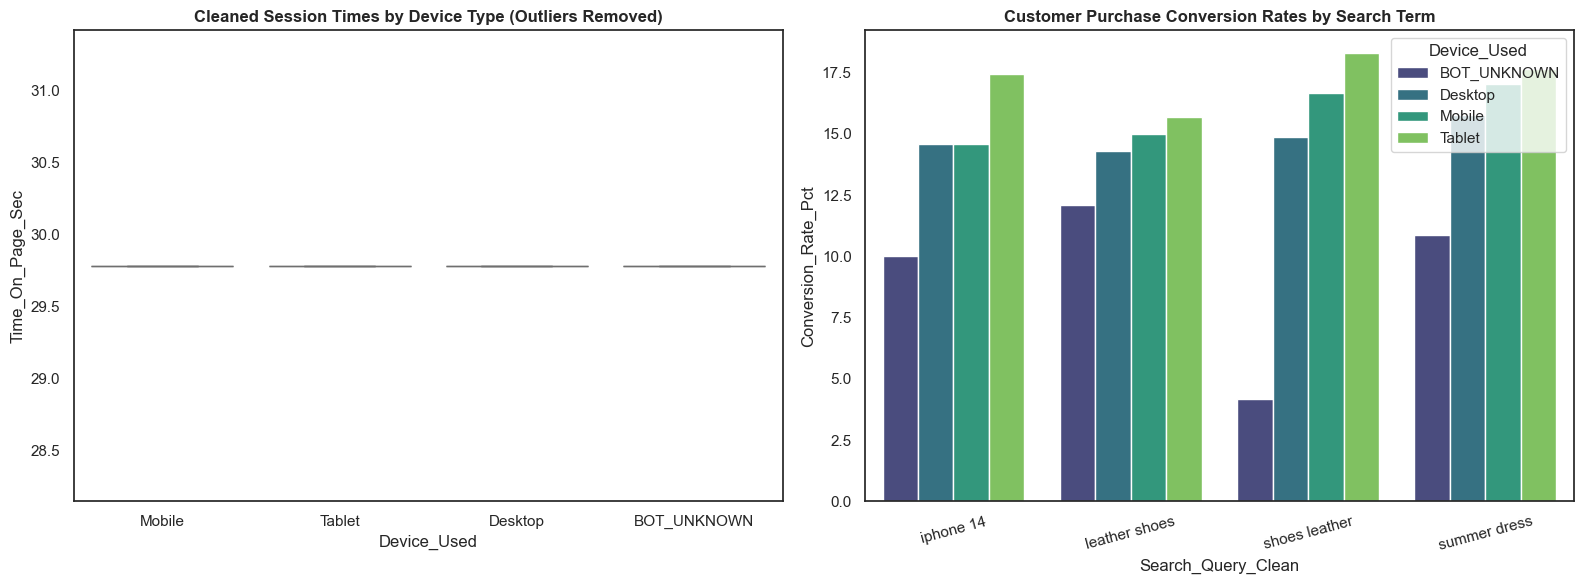

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

df = pd.read_csv('raw_web_traffic.csv')

print("=== 📊 STEP 1: INITIAL SUMMARY STATISTICS ===")
print(df['Time_On_Page_Sec'].describe())
print("=========================================\n")

# =====================================================================
# 1. TEXT UNIFICATION & CLEANING
# =====================================================================
# Fix queries: " leather shoes " and "  shoes leather  " should be treated identically
df['Search_Query_Clean'] = df['Search_Query_Raw'].str.strip().str.lower()
df['Search_Query_Clean'] = df['Search_Query_Clean'].replace({'n/a': np.nan})

# High-priority drop: if they didn't search for anything, drop the session
df = df.dropna(subset=['Search_Query_Clean'])


Q1 = df['Time_On_Page_Sec'].quantile(0.25)  # 25th percentile (First Quartile)
Q3 = df['Time_On_Page_Sec'].quantile(0.75)  # 75th percentile (Third Quartile)
IQR = Q3 - Q1

# Anything beyond 1.5 times the IQR above the 75th percentile is statistically a rogue outlier (Bot)
upper_limit = Q3 + (1.5 * IQR)

print(f"=== 🧼 STEP 2: IQR BOT DETECTION CRITERIA ===")
print(f"Normal Customer Range Boundary: Up to {upper_limit:.2f} seconds.")

# Clean the data by applying the IQR mask
df_cleaned = df[df['Time_On_Page_Sec'] <= upper_limit]
print(f"Rows Before IQR Filter: {df.shape[0]} | Rows After (Bots Removed): {df_cleaned.shape[0]}")
print("=========================================\n")

# =====================================================================
# 3. MARKETING AGGREGATION
# =====================================================================
marketing_summary = df_cleaned.groupby(['Device_Used', 'Search_Query_Clean']).agg(
    Total_Clicks=('Session_ID', 'count'),
    Avg_Seconds_On_Page=('Time_On_Page_Sec', 'mean'),
    Conversion_Rate_Pct=('Purchase_Made', lambda x: x.mean() * 100)
).reset_index()

# =====================================================================
# 4. DATA VISUALIZATION
# =====================================================================
sns.set_theme(style="white")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot A: Boxplot showing how IQR isolated normal users from outliers
sns.boxplot(x='Device_Used', y='Time_On_Page_Sec', data=df_cleaned, palette='pastel', ax=axes[0])
axes[0].set_title('Cleaned Session Times by Device Type (Outliers Removed)', fontweight='bold')

# Plot B: Barplot showing conversion success rates per query
sns.barplot(x='Search_Query_Clean', y='Conversion_Rate_Pct', hue='Device_Used', data=marketing_summary, palette='viridis', ax=axes[1])
axes[1].set_title('Customer Purchase Conversion Rates by Search Term', fontweight='bold')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()